<table align="left"><tr><td>
<a href="https://colab.research.google.com/github/kikim6114/nlp2026/blob/main/03.Word_Embedding-2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="코랩에서 실행하기"/></a>
</td></tr></table>

<font face="Times New Roman" size=7 color='blue'>3. 단어 임베딩(Word Embedding)-2<font>

In [ ]:
# Colab이나 Kaggle을 사용하는 경우가 아니면, 이 cell을 모두 주석화하여 skip할 것.
import os

repository_name = 'nlp2026'
repository_url = f'https://github.com/kikim6114/{repository_name}.git'

# 항상 루트 경로(/content/)로 이동 후 확인
%cd /content/

if not os.path.exists(repository_name):
    !git clone {repository_url}
    print(f"{repository_name} 클론 완료")
else:
    print(f"{repository_name} 폴더가 이미 존재합니다. 클론을 건너뜁니다.")
%cd nlp2026

이 자료는 다음 자료들을 기반으로 수정된 자료입니다.<br>
- [위키독스 딥 러닝을 이용한 자연어 처리 입문, 09. 워드 임베딩(Word Embedding)](https://wikidocs.net/22644)

## Gensim
- NLP를 위한 오픈 소스 파이썬 라이브러리로, 특히 Topic Modeling과 Documents Similarity Analysis에 초점을 맞춤
- Gensim(Generate Similar)
- 대용량 텍스트 데이터의 효율적 처리가 가능하도록 설계됨
- Topic Modeling: Latent Dirichlet Allocation(LDA), Latent Semantic Analysis(LSA)
- Similarity : 코사인 유사도, 유클리드 거리 등 다양한 메트릭을 사용하여 문서 간 유사성을 계산
- 단어 임베딩: Word2Vec, FastText 등
- Data streamed algorithm을 사용하여 데이터가 메모리보다 커도 처리할 수 있음
- 

In [ ]:
import sys
!{sys.executable} -m pip install gensim

   ---------------------------------------- 0.0/24.0 MB ? eta -:--:--
   --------------------- ------------------ 12.8/24.0 MB 66.9 MB/s eta 0:00:01
   ---------------------------------------  23.9/24.0 MB 65.5 MB/s eta 0:00:01
   ---------------------------------------- 24.0/24.0 MB 58.4 MB/s eta 0:00:00


In [2]:
import gensim
gensim.__version__

'4.3.3'

In [3]:
import sys
!{sys.executable} -m pip install konlpy

# 3.1. word2vec (영어)

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\kikim\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [7]:
import urllib.request
import zipfile
from lxml import etree   # XML과 HTML parsing 하기 위해 lxml에서 element tree 를 import
import re
from nltk.tokenize import word_tokenize, sent_tokenize

In [6]:
# 데이터 다운로드
urllib.request.urlretrieve("https://raw.githubusercontent.com/ukairia777/tensorflow-nlp-tutorial/main/09.%20Word%20Embedding/dataset/ted_en-20160408.xml", filename="ted_en-20160408.xml")

('ted_en-20160408.xml', <http.client.HTTPMessage at 0x20577126af0>)

#### [실행시간 약간 긴 편]

In [8]:
targetXML = open('ted_en-20160408.xml', 'r', encoding='UTF8')
target_text = etree.parse(targetXML)  

# xml 파일로부터 <content>와 </content> 사이의 내용만 가져온다.
parse_text = '\n'.join(target_text.xpath('//content/text()'))

# 정규 표현식의 sub 모듈을 통해 content 중간에 등장하는 (Audio), (Laughter) 등의 배경음 부분을 제거.
# 해당 코드는 괄호로 구성된 내용을 제거.
content_text = re.sub(r'\([^)]*\)', '', parse_text)

# 입력 코퍼스에 대해서 NLTK를 이용하여 문장 토큰화를 수행.
sent_text = sent_tokenize(content_text)

# 각 문장에 대해서 구두점을 제거하고, 대문자를 소문자로 변환.
normalized_text = []
for string in sent_text:
    tokens = re.sub(r"[^a-z0-9]+", " ", string.lower())
    normalized_text.append(tokens)

# 각 문장에 대해서 NLTK를 이용하여 단어 토큰화를 수행.
result = [word_tokenize(sentence) for sentence in normalized_text]

In [12]:
print('총 샘플의 개수 : {}'.format(len(result)))

총 샘플의 개수 : 273424


In [13]:
# 샘플 3개만 출력
for line in result[:3]:
    print(line)

['here', 'are', 'two', 'reasons', 'companies', 'fail', 'they', 'only', 'do', 'more', 'of', 'the', 'same', 'or', 'they', 'only', 'do', 'what', 's', 'new']
['to', 'me', 'the', 'real', 'real', 'solution', 'to', 'quality', 'growth', 'is', 'figuring', 'out', 'the', 'balance', 'between', 'two', 'activities', 'exploration', 'and', 'exploitation']
['both', 'are', 'necessary', 'but', 'it', 'can', 'be', 'too', 'much', 'of', 'a', 'good', 'thing']


In [14]:
from gensim.models import Word2Vec
from gensim.models import KeyedVectors

In [15]:
model = Word2Vec(sentences=result, vector_size=100, window=5, min_count=5, workers=4, sg=0)

* vector_size = 워드 벡터의 특징 값. 즉, 임베딩 된 벡터의 차원.
* window = 컨텍스트 윈도우 크기
* min_count = 단어 최소 빈도 수 제한 (빈도가 적은 단어들은 학습하지 않는다.)
* workers = 학습을 위한 프로세스 수
* sg = 0은 CBOW, 1은 Skip-gram.

In [21]:
model_result = model.wv.most_similar("man")
print(model_result)

[('woman', 0.8434939980506897), ('guy', 0.8297913074493408), ('lady', 0.7871298789978027), ('boy', 0.7742692232131958), ('girl', 0.7486547231674194), ('gentleman', 0.7464945316314697), ('kid', 0.726730227470398), ('soldier', 0.726700484752655), ('david', 0.663236677646637), ('friend', 0.6625813841819763)]


In [22]:
model.wv.save_word2vec_format('eng_w2v') # 모델 저장
loaded_model = KeyedVectors.load_word2vec_format("eng_w2v") # 모델 로드

In [23]:
model_result = loaded_model.most_similar("man")
print(model_result)

[('woman', 0.8434939980506897), ('guy', 0.8297913074493408), ('lady', 0.7871298789978027), ('boy', 0.7742692232131958), ('girl', 0.7486547231674194), ('gentleman', 0.7464945316314697), ('kid', 0.726730227470398), ('soldier', 0.726700484752655), ('david', 0.663236677646637), ('friend', 0.6625813841819763)]


# 3.2 word2vec (한국어)

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request
from tqdm import tqdm
from gensim.models.word2vec import Word2Vec
from konlpy.tag import Okt

In [25]:
urllib.request.urlretrieve("https://raw.githubusercontent.com/e9t/nsmc/master/ratings.txt", filename="ratings.txt")

('ratings.txt', <http.client.HTTPMessage at 0x20598070f70>)

In [26]:
train_data = pd.read_table('ratings.txt')

In [27]:
train_data[:5] # 상위 5개 출력

,id,document,label
0,8112052,어릴때보고 지금다시봐도 재밌어요ㅋㅋ,1
1,8132799,"디자인을 배우는 학생으로, 외국디자이너와 그들이 일군 전통을 통해 발전해가는 문화산...",1
2,4655635,폴리스스토리 시리즈는 1부터 뉴까지 버릴께 하나도 없음.. 최고.,1
3,9251303,와.. 연기가 진짜 개쩔구나.. 지루할거라고 생각했는데 몰입해서 봤다.. 그래 이런...,1
4,10067386,안개 자욱한 밤하늘에 떠 있는 초승달 같은 영화.,1


In [30]:
print('리뷰 개수 :',len(train_data))

리뷰 개수 : 200000


In [31]:
print('NULL 값 존재 유무 :', train_data.isnull().values.any())

NULL 값 존재 유무 : True


In [34]:
train_data = train_data.dropna(how = 'any') # Null 값이 존재하는 행 제거
print('NULL 값 존재 유무 :', train_data.isnull().values.any()) # Null 값이 존재하는지 확인

NULL 값 존재 유무 : False


In [35]:
print('리뷰 개수 :',len(train_data))

리뷰 개수 : 199992


In [36]:
# 정규 표현식을 통한 한글 외 문자 제거
train_data['document'] = train_data['document'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]","")

In [37]:
train_data[:5] # 상위 5개 출력

,id,document,label
0,8112052,어릴때보고 지금다시봐도 재밌어요ㅋㅋ,1
1,8132799,"디자인을 배우는 학생으로, 외국디자이너와 그들이 일군 전통을 통해 발전해가는 문화산...",1
2,4655635,폴리스스토리 시리즈는 1부터 뉴까지 버릴께 하나도 없음.. 최고.,1
3,9251303,와.. 연기가 진짜 개쩔구나.. 지루할거라고 생각했는데 몰입해서 봤다.. 그래 이런...,1
4,10067386,안개 자욱한 밤하늘에 떠 있는 초승달 같은 영화.,1


In [38]:
# 불용어 정의
stopwords = ['의','가','이','은','들','는','좀','잘','걍','과','도','를','으로','자','에','와','한','하다']

#### <span style="color: crimson">[주의🐞]</span> 다음 cell의 토큰화 작업은 시간이 소요되므로, 저장된 `ratings_tokenized` 이 있으면 다음 cell을 skip하고 그 다음 다음 cell의 방법으로 로드하여 사용하자.

In [ ]:
# 형태소 분석기 OKT를 사용한 토큰화 작업 (10분 정도 소요)
okt = Okt()

tokenized_data = []
for sentence in tqdm(train_data['document']):
    tokenized_sentence = okt.morphs(sentence, stem=True) # 토큰화
    stopwords_removed_sentence = [word for word in tokenized_sentence if not word in stopwords] # 불용어 제거
    tokenized_data.append(stopwords_removed_sentence)

100%|█████████████████████████████████████████████████████████████████████████| 199992/199992 [09:26<00:00, 352.78it/s]


In [ ]:
# 실습 중 대기 시간을 줄이기 위해 저장함
import json
with open("ratings_tokenized", "w") as fp:
    json.dump(tokenized_data, fp)

#### 저장해 놓은 `ratings_tokenized` 파일 로드
- 위 cell에서 토큰화 작업을 처음 했으면 이 cell은 skip

In [ ]:
import json
with open("ratings_tokenized", "r") as fp:
    tokenized_data = json.load(fp)

In [27]:
print(tokenized_data[:3])

[['어리다', '때', '보고', '지금', '다시', '보다', '재밌다', 'ㅋㅋ'], ['디자인', '을', '배우다', '학생', ',', '외국', '디자이너', '그', '일군', '전통', '을', '통해', '발전', '문화', '산업', '부럽다', '.', '사실', '우리나라', '에서도', '그', '어렵다', '시절', '끝', '까지', '열정', '을', '지키다', '노라노', '같다', '전통', '있다', '저', '같다', '사람', '꿈', '을', '꾸다', '이루다', '나가다', '수', '있다', '것', '감사하다', '.'], ['폴리스스토리', '시리즈', '1', '부터', '뉴', '까지', '버리다', '하나', '없다', '..', '최고', '.']]


리뷰의 최대 길이 : 95
리뷰의 평균 길이 : 12.338453538141525


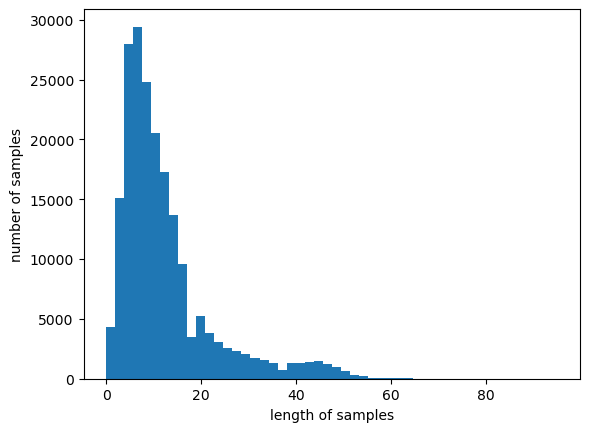

In [28]:
# 리뷰 길이 분포 확인
print('리뷰의 최대 길이 :',max(len(l) for l in tokenized_data))
print('리뷰의 평균 길이 :',sum(map(len, tokenized_data))/len(tokenized_data))
plt.hist([len(s) for s in tokenized_data], bins=50)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

In [38]:
from gensim.models import Word2Vec

In [29]:
model = Word2Vec(sentences = tokenized_data, vector_size = 100, window = 5, min_count = 5, workers = 4, sg = 0)

In [30]:
print('완성된 임베딩 매트릭스의 크기 확인 :', model.wv.vectors.shape)

완성된 임베딩 매트릭스의 크기 확인 : (17615, 100)


In [31]:
print(model.wv.most_similar("최민식"))

[('한석규', 0.8421459794044495), ('워싱턴', 0.8259050250053406), ('최민수', 0.824555516242981), ('서영희', 0.8087553381919861), ('김명민', 0.800811767578125), ('이민호', 0.7967878580093384), ('공리', 0.7937867045402527), ('엄정화', 0.7923246622085571), ('이주승', 0.7863762974739075), ('이정재', 0.7837391495704651)]


In [32]:
print(model.wv.most_similar("히어로"))

[('슬래셔', 0.8434402346611023), ('호러', 0.8161230683326721), ('무협', 0.8078081607818604), ('블록버스터', 0.8054512143135071), ('정통', 0.8044179081916809), ('느와르', 0.8021231889724731), ('물', 0.8016476631164551), ('물의', 0.7929428815841675), ('판타지', 0.7887967228889465), ('sf', 0.7800137996673584)]


In [33]:
print(model.wv.most_similar("발연기"))

[('발음', 0.7579474449157715), ('연기', 0.7561862468719482), ('연기력', 0.7181985974311829), ('조연', 0.7158408761024475), ('어색', 0.7036996483802795), ('사투리', 0.6907298564910889), ('미스캐스팅', 0.6681576371192932), ('주연', 0.6641914248466492), ('권상우', 0.6549423336982727), ('목소리', 0.6546614766120911)]


# 3.3 사전 훈련된 word2vec

In [34]:
import gensim
import urllib.request

#### 직접 다운로드 받아서 사용
- 직접 다운로드: [GoogleNews-vectors-negative300.bin.gz](https://drive.google.com/file/d/0B7XkCwpI5KDYNlNUTTlSS21pQmM/edit?usp=sharing)

In [ ]:
# 이미 install하지 않았으면 install
!pip install gdown

`GoogleNews-vectors-negative300.bin.gz`를 이미 한번 다운로드 했으면 아래 cell을 skip하고 다음 cell에서 모델을 로드하자.

In [ ]:
import gensim
import os

# GoogleNews-vectors-negative300.bin.gz 을 위한 Google Drive 파일 ID를 정의
# 이 ID는 원래 노트북에 제시된 다운로드 링크에서 가져온 것이다.
file_id = '0B7XkCwpI5KDYNlNUTTlSS21pQmM'
output_filename = 'GoogleNews-vectors-negative300.bin.gz'

# 기존에 손상된 파일이 있는 경우 삭제하여 새 다운로드를 진행하는 것이 좋다.
if os.path.exists(output_filename):
    print(f"기존에 손상된 파일 삭제: {output_filename}")
    os.remove(output_filename)

print(f"구글 드라이브에서 {output_filename} 다운로드 중...")
# gdown을 사용하여 파일 다운로드
!gdown --id {file_id} -O {output_filename}
print("다운로드 완료.")

In [ ]:
# 다운로드된 모델 로드
# [주목] 이 파일은 매우 크므로 (약 3.6GB), 로딩에 시간이 걸릴 수 있다.
word2vec_model = gensim.models.KeyedVectors.load_word2vec_format(output_filename, binary=True)

In [37]:
print(word2vec_model.vectors.shape)

(3000000, 300)


In [38]:
print(word2vec_model.similarity('this', 'is'))
print(word2vec_model.similarity('post', 'book'))

0.40797037
0.057204388


In [39]:
print(word2vec_model['book'])

[ 0.11279297 -0.02612305 -0.04492188  0.06982422  0.140625    0.03039551
 -0.04370117  0.24511719  0.08740234 -0.05053711  0.23144531 -0.07470703
  0.21875     0.03466797 -0.14550781  0.05761719  0.00671387 -0.00701904
  0.13183594 -0.25390625  0.14355469 -0.140625   -0.03564453 -0.21289062
 -0.24804688  0.04980469 -0.09082031  0.14453125  0.05712891 -0.10400391
 -0.19628906 -0.20507812 -0.27539062  0.03063965  0.20117188  0.17382812
  0.09130859 -0.10107422  0.22851562 -0.04077148  0.02709961 -0.00106049
  0.02709961  0.34179688 -0.13183594 -0.078125    0.02197266 -0.18847656
 -0.17480469 -0.05566406 -0.20898438  0.04858398 -0.07617188 -0.15625
 -0.05419922  0.01672363 -0.02722168 -0.11132812 -0.03588867 -0.18359375
  0.28710938  0.01757812  0.02185059 -0.05664062 -0.01251221  0.01708984
 -0.21777344 -0.06787109  0.04711914 -0.00668335  0.08544922 -0.02209473
  0.31835938  0.01794434 -0.02246094 -0.03051758 -0.09570312  0.24414062
  0.20507812  0.05419922  0.29101562  0.03637695  0.04